In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../outputs/csv/wifi-2026/persta_bursty.csv")



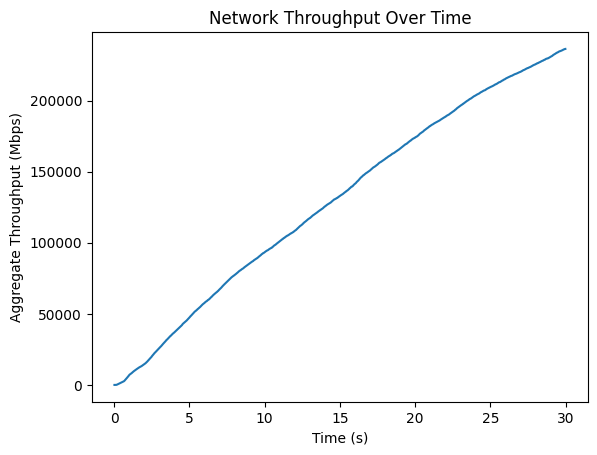

In [15]:
g = df.groupby("time").agg({
    "throughput": "sum",
    "delay": "mean",
    "jitter": "mean",
    "loss": "mean"
})

plt.figure()
g["throughput"].plot()
plt.ylabel("Aggregate Throughput (Mbps)")
plt.xlabel("Time (s)")
plt.title("Network Throughput Over Time")
plt.show()

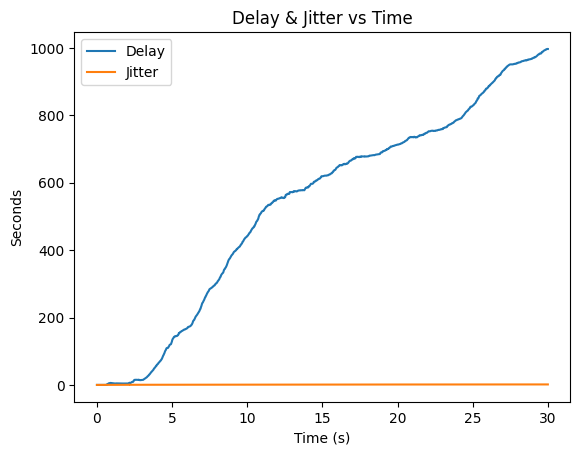

In [16]:
plt.figure()
g["delay"].plot(label="Delay")
g["jitter"].plot(label="Jitter")
plt.legend()
plt.ylabel("Seconds")
plt.xlabel("Time (s)")
plt.title("Delay & Jitter vs Time")
plt.show()


In [17]:
states = ["LOS", "Mid", "NLOS"]

plt.figure(figsize=(10, 6))

for s in states:
    # Filter by the string label and plot the mean throughput over time
    subset = df[df.los_state == s]
    if not subset.empty:
        subset.groupby("time")["throughput_Mbps"].mean().plot(label=s)

plt.legend(title="LOS State")
plt.ylabel("Throughput (Mbps)")
plt.xlabel("Time (s)")
plt.title("Throughput by LOS State")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


KeyError: 'Column not found: throughput_Mbps'

<Figure size 1000x600 with 0 Axes>

<Figure size 600x400 with 0 Axes>

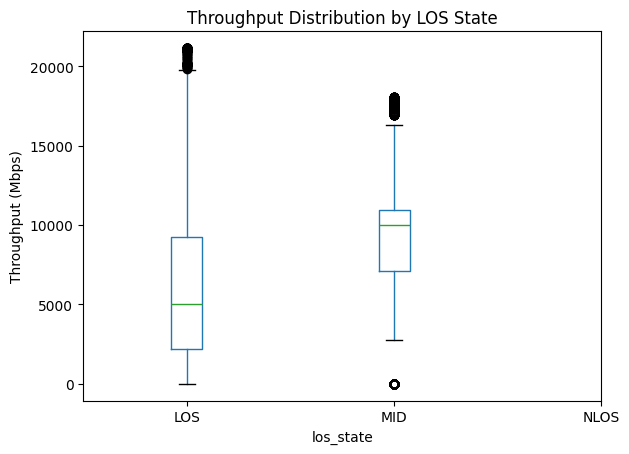

In [19]:
plt.figure(figsize=(6,4))
df.boxplot(
    column="throughput",
    by="los_state",
    grid=False
)
plt.xticks([1,2,3], ["LOS", "MID", "NLOS"])
plt.ylabel("Throughput (Mbps)")
plt.title("Throughput Distribution by LOS State")
plt.suptitle("")
plt.tight_layout()
plt.show()


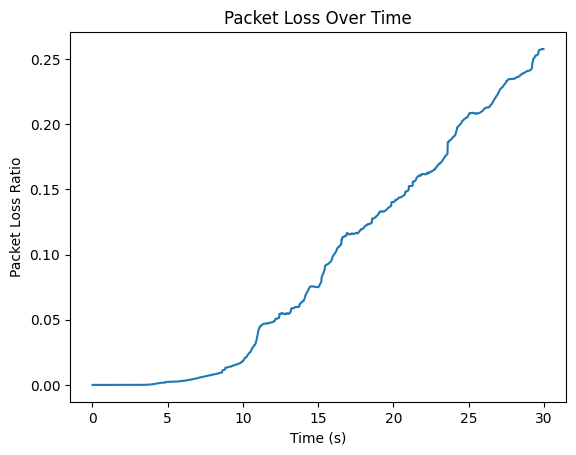

In [21]:
plt.figure()
g["loss"].plot()
plt.ylabel("Packet Loss Ratio")
plt.xlabel("Time (s)")
plt.title("Packet Loss Over Time")
plt.show()


In [22]:
active_users = df.groupby("time")["active"].sum()

plt.figure()
active_users.plot()
plt.ylabel("Active STAs")
plt.xlabel("Time (s)")
plt.title("Active User Count Over Time")
plt.show()


KeyError: 'Column not found: active'

In [23]:
active_users = df.groupby("time")["active"].sum()

plt.figure()
active_users.plot()
plt.ylabel("Active STAs")
plt.xlabel("Time (s)")
plt.title("Active User Count Over Time")
plt.show()


KeyError: 'Column not found: active'

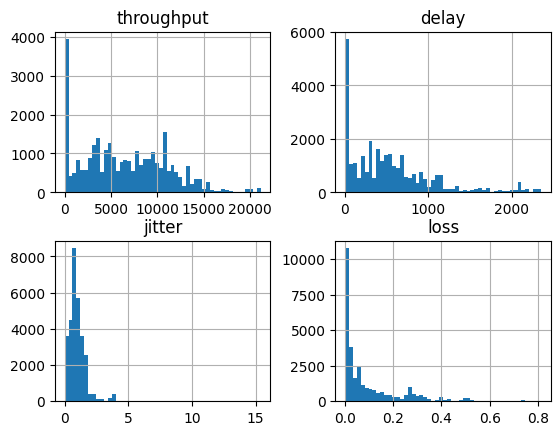

In [24]:
df[["throughput","delay","jitter","loss"]].hist(bins=50)
plt.show()
